In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Realizando leitura do arquivo

In [2]:
dados = pd.read_csv(r"../data/raw/desafio_nps_fase_1.csv")
dados.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


####
------------

#### Verificando as dimensões da base de dados

In [3]:
print(f'O dataset de NPS contém o seguinte formato (Linhas, Colunas): {dados.shape}')

O dataset de NPS contém o seguinte formato (Linhas, Colunas): (2500, 19)


####
-------------

#### Verificando tipos de dados

In [4]:
dados.dtypes

customer_id                    int64
customer_age                   int64
customer_region                  str
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

Podemos observar que campos como "customer_id", "order_id" estão sendo lidos como int64, quando deveriam estar sendo tratados como strings, já que representam um identificador único. Vamos realizar uma transformação para transformar essas colunas em string.

In [5]:
# Aplicando tipo de str na coluna customer_id
dados['customer_id'] = dados['customer_id'].astype('str')

# Aplicando tipo de str na coluna order_id
dados['order_id'] = dados['order_id'].astype('str')

####
---------------

#### Verificando existência de valores nulos

In [6]:
print(dados.isnull().sum())
print(f'\nA base contém {dados.isnull().sum().sum()} valores nulos.')

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

A base contém 0 valores nulos.


A base não contém nenhum valor nulo, portanto, não é necessário fazer tratamento nessa etapa.

####
---------------------

#### Criando coluna para categorizar as notas

In [7]:
def categorizar(nps_score):
    if nps_score < 7:
        return 'Detrator'
    elif nps_score < 9:
        return 'Neutro'
    else:
        return 'Promotor'

dados['categoria_nps'] = dados['nps_score'].apply(categorizar)

Agora podemos observar que notas da categoria 'Detrator' representam de fato a maior parte da base de dados

In [8]:
dados['categoria_nps'].value_counts()

categoria_nps
Detrator    2109
Neutro       281
Promotor     110
Name: count, dtype: int64

#### 
-------------------------

#### Descrevendo a base (estatísticas descritivas) | Histograma

Na célula abaixo podemos observar que a média de NPS é baixa (4.38) e que até mesmo o terceiro quartil (3Q) se encaixa dentro da categoria de detratores. Isso já nos indica que a avaliação dos clientes quanto ao serviço prestado tende a ser negativa.

In [9]:
dados.describe().round(2)

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,43.40,61.32,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,14.89,34.48,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,18.00,1.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,31.00,31.00,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,43.00,62.00,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,56.00,91.00,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,69.00,119.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


No gráfico de histograma abaixo podemos observar a distribuição da frequência de cada nota, reforçando o achado anterior de que as notas são majoritariamente de clientes que se enquadram na categoria de detratores. Além disso, podemos observar um pico nas notas de 0 a 1, reforçando mais ainda o descontentamento dos clientes.

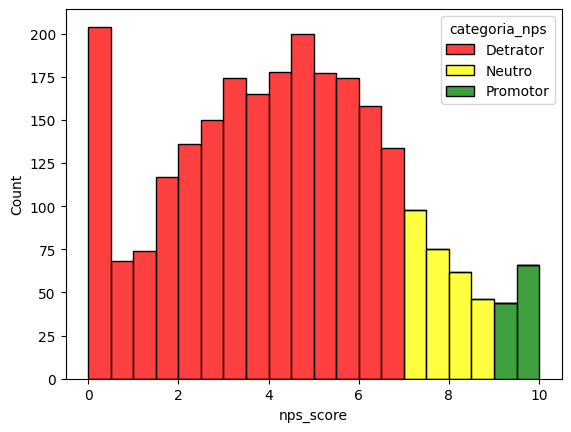

In [10]:
paleta = {
    'Detrator':'red',
    'Neutro':'yellow',
    'Promotor':'green'
}


sns.histplot(data=dados, x='nps_score', hue='categoria_nps', multiple='stack', palette=paleta)
plt.show()

####
--------------

#### Análise de correlação entre variáveis

In [11]:
# Selecionando apenas colunas numéricas
df_num = dados.select_dtypes(include=['number'])

Plotando um gráfico de correlação abaixo podemos tirar as seguintes conclusões:
- A coluna repeat_purchase_30d apresenta uma correlação positiva com o nps_score, o que pode indicar que clientes satisfeitos tendem a realizar uma recompra. Esse dado reforça ainda mais a ideia de que melhorando a jornada do cliente sua percepção sobre o serviço prestado há potencial direto para aumento de vendas.
- Muitas variáveis que em um primeiro momento poderia se pensar que estavam relacionadas com a percepção do cliente na verdade apresentam correlação muito baixa com o nps_score. Dentre elas destacam-se discount_value, delivery_time_days e freight_value. O que isso nos indica é que para o cenário atual do e-commerce o valor do desconto fornecido, o prazo pra entrega e o valor do frete não impactam muito no score final do NPS, o que nos sugere que há algum outro fator que está pesando mais na experiência do cliente.
- Chegamos então nos campos que apresentam maior correlação negativa com o NPS Score: tempo de atraso na entrega (delivery_delay_days), número de reclamações (complaints_count), número de contatos do cliente com o atendimento (customer_service_contacts) e o tempo para resolução do problema (resolution_time_days). 

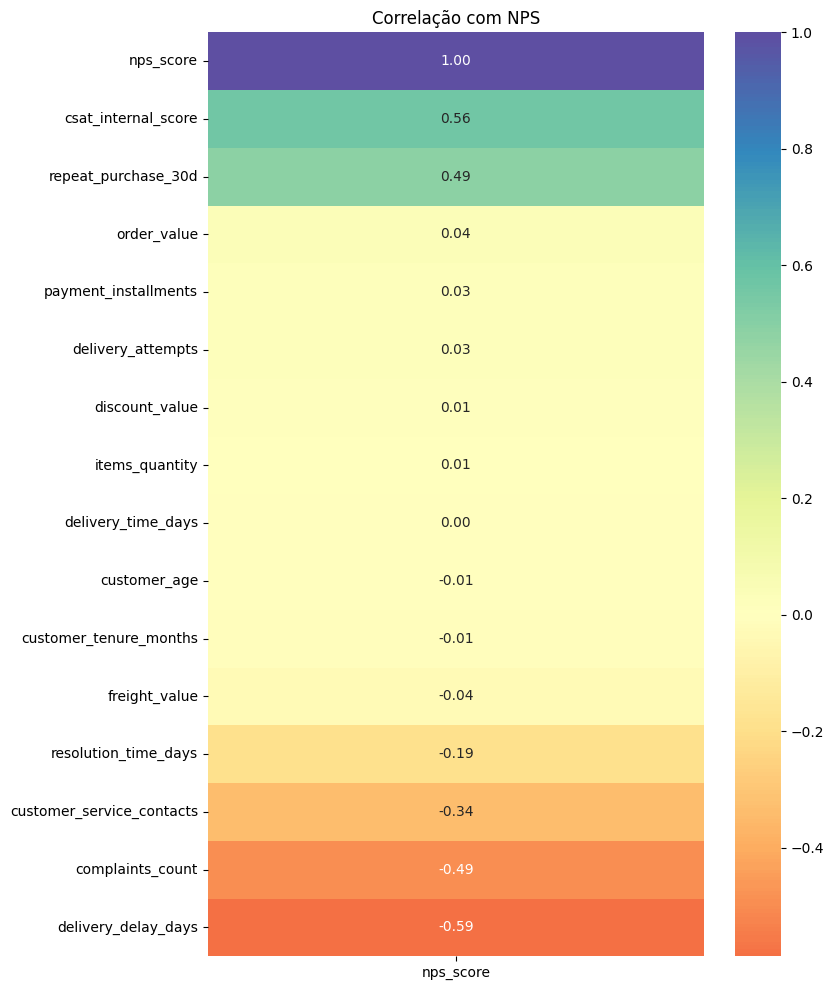

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculando a correlação utilizando método de Spearman
corr = df_num.corr(method='spearman')
corr_nps = corr['nps_score'].sort_values(ascending=False)


# Plotando matriz de correlação
plt.figure(figsize=(8, 12))
sns.heatmap(corr_nps.to_frame(), annot=True, cmap='Spectral', center=0, fmt=".2f")
plt.title('Correlação com NPS')
plt.show()

####
-------------

#### Scatterplot

O Scatterplot abaixo demonstra visualmente a correlação negativa entre os dias de atraso na entrega e o NPS Score. Quanto menor o tempo de atraso, maior tende a ser a nota do NPS fornecida pelo cliente.

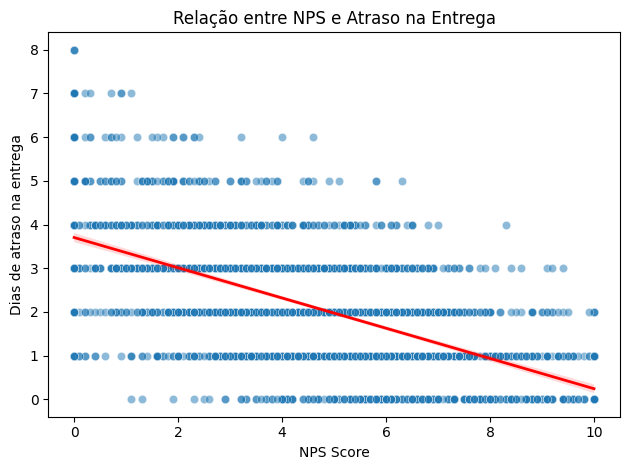

In [13]:
sns.scatterplot(data=dados, x="nps_score", y="delivery_delay_days", alpha=0.5)

# Linha de tendência com regplot
sns.regplot(
         data=dados,
        x="nps_score",
        y="delivery_delay_days",
        scatter=False,            # não recria os pontos
        color="red",              # linha de tendência em vermelho
        line_kws={"linewidth": 2} # deixa a linha mais grossa
    )

plt.title("Relação entre NPS e Atraso na Entrega")
plt.xlabel("NPS Score")
plt.ylabel("Dias de atraso na entrega")
plt.tight_layout()
plt.show()